# Superconducting Resonator — Time-Sweep S₂₁ Analysis

Performs DCM (Diameter Correction Method) circle fitting on a time series of
S₂₁ measurements using the **original fitting routines** from
[WeiRenSyong/Fitting\_Code\_Lab\_2.0](https://github.com/WeiRenSyong/Fitting_Code_Lab_2.0),
then plots the fitted parameters (Qᵢ, Qc, φ, fс) and their power spectral densities.

**Dependencies:** `numpy`, `pandas`, `matplotlib`, `scipy` — plus the packages
required by Fitting\_Code\_Lab\_2.0 (`lmfit`, `uncertainties`, `attr`, `attrs`,
`inflect`, `regex`), which are already installed if you have run the repository.

## ① Configuration — edit this cell

In [ ]:
# ============================================================
#  SET YOUR DATA FOLDER PATH HERE
# ============================================================
MAIN_FOLDER = r"C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21"

# ============================================================
#  SET THE PATH TO YOUR Fitting_Code_Lab_2.0 REPOSITORY
# ============================================================
# This is needed so the notebook can import the fitting routines directly.
REPO_PATH = r"C:\Users\user\OneDrive\文件\GitHub\Fitting_Code_Lab_2.0"

# ── Optional settings ────────────────────────────────────────
SAVE_PLOTS        = True   # Save summary PNG figures alongside the data
SAVE_CSVS         = True   # Save fitted parameters as CSV files
SAVE_CIRCLE_PLOTS = True   # Save one circle-fit PNG per data file (repo format)

## ② Imports & setup

In [130]:
import logging
import re
import shutil
import sys
import tempfile
from pathlib import Path
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit, least_squares

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120})

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s",
    datefmt="%H:%M:%S",
)
log = logging.getLogger(__name__)

# Column indices in time_sweep_summary.csv (0-indexed)
SUMMARY_COL_TIMESTAMP = 3   # column D
SUMMARY_COL_POWER     = 5   # column F

PARAM_LABELS = {
    "Qi":  r"$Q_i$",
    "Qc":  r"$Q_c$",
    "phi": r"$\phi$ (rad)",
    "fc":  r"$f_c$ (GHz)",
}

## ③ Load the Fitting\_Code\_Lab\_2.0 repository

Adds the repo's `scresonators` package to the Python path so we can call
`fit_resonator.fit.fit()` and `fit_resonator.resonator.Resonator()` directly —
the exact same routines used for power-sweep analysis.

In [131]:
repo_path = Path(REPO_PATH).resolve()
if not repo_path.is_dir():
    raise FileNotFoundError(
        f"Repository not found: {repo_path}\n"
        "Please update REPO_PATH in the Configuration cell above."
    )

scresonators_path = repo_path / "scresonators"
if not scresonators_path.is_dir():
    raise FileNotFoundError(
        f"'scresonators' subfolder not found inside {repo_path}\n"
        "Check that REPO_PATH points to the root of Fitting_Code_Lab_2.0."
    )

# Insert at the front so the repo's modules take priority
if str(scresonators_path) not in sys.path:
    sys.path.insert(0, str(scresonators_path))

import fit_resonator.fit       as fsd
import fit_resonator.resonator as res

print(f"fit_resonator.fit      : {fsd.__file__}")
print(f"fit_resonator.resonator: {res.__file__}")
print("Repository loaded successfully.")

fit_resonator.fit      : C:\Users\user\OneDrive\文件\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\fit.py
fit_resonator.resonator: C:\Users\user\OneDrive\文件\GitHub\Fitting_Code_Lab_2.0\scresonators\fit_resonator\resonator.py
Repository loaded successfully.


## ④ Directory parsing

Reads `time_sweep_summary.csv`, groups rows by input power, sorts each group
chronologically, and maps them to the actual CSV files in each subfolder.

In [132]:
def parse_main_folder(main_folder: Path) -> Dict[str, List[Tuple]]:
    """
    Returns a dict:  power_label -> [(timestamp, csv_path), ...]
    Timestamps are sorted chronologically and mapped to the numbered CSV files.
    """
    summary_path = main_folder / "time_sweep_summary.csv"
    if not summary_path.exists():
        raise FileNotFoundError(f"Summary file not found: {summary_path}")

    df = pd.read_csv(summary_path, header=0)
    min_cols = max(SUMMARY_COL_TIMESTAMP, SUMMARY_COL_POWER) + 1
    if df.shape[1] < min_cols:
        raise ValueError(
            f"time_sweep_summary.csv has only {df.shape[1]} columns; "
            f"expected at least {min_cols}."
        )

    timestamps_raw = df.iloc[:, SUMMARY_COL_TIMESTAMP]
    powers_raw     = df.iloc[:, SUMMARY_COL_POWER]

    try:
        timestamps = pd.to_datetime(timestamps_raw, unit="s", utc=True)
    except Exception:
        try:
            timestamps = pd.to_datetime(timestamps_raw, format="mixed", utc=True)
        except TypeError:
            timestamps = pd.to_datetime(
                timestamps_raw, infer_datetime_format=True, utc=True
            )

    powers = powers_raw.astype(str).str.strip()

    def _normalise_power(p: str) -> str:
        p = p.strip()
        if re.fullmatch(r"-?\d+(\.\d+)?", p):
            return p + "dBm"
        return p

    powers = powers.apply(_normalise_power)

    power_map: Dict[str, List[Tuple]] = {}
    for pwr in powers.unique():
        mask    = powers == pwr
        ts_grp  = timestamps[mask].sort_values()
        pwr_dir = main_folder / pwr

        if not pwr_dir.is_dir():
            log.warning("Power subfolder not found, skipping: %s", pwr_dir)
            continue

        def _sort_key(p):
            m = re.search(r"(\d+)\.csv$", p.name, re.IGNORECASE)
            return int(m.group(1)) if m else -1

        found_csvs = sorted(
            [p for p in pwr_dir.glob("*.csv")
             if re.search(r"\d+\.csv$", p.name, re.IGNORECASE)],
            key=_sort_key,
        )

        if not found_csvs:
            log.warning("No numbered CSV files found in: %s", pwr_dir)
            continue

        if len(found_csvs) != len(ts_grp):
            log.warning(
                "Power %s: %d timestamps in summary but %d CSV files — "
                "mapping by position up to the shorter count.",
                pwr, len(ts_grp), len(found_csvs),
            )

        entries = [(ts, csv_path) for ts, csv_path in zip(ts_grp, found_csvs)]
        if entries:
            power_map[pwr] = entries

    if not power_map:
        raise RuntimeError("No valid power/data pairings were found.")

    log.info("Found %d power level(s): %s", len(power_map), sorted(power_map.keys()))
    return power_map

## ⑤ Fitting with the repository's DCM routine

`fit_one_file()` calls `fit_resonator.fit.fit()` — the **exact same function**
used by `fit_single_res()` in `helper_fit.py` for power-sweep analysis.

Because the repository saves its PNG relative to the CSV file's location,
we first copy each CSV to a temporary folder, run the fit there, then move
the output PNG to sit next to the original CSV.

In [133]:
def fit_one_file(
    csv_path: Path,
    save_png: bool = True,
    MC_iteration: int = 10,
    MC_rounds: int    = 10,
    MC_step_const: float = 0.3,
) -> Optional[Dict]:
    """
    Fit a single S21 CSV using the repository's DCM routine.

    The file is copied to a temporary folder so the repository can write
    its output PNG alongside it.  The PNG is then moved next to the
    original CSV, matching the format produced by power-sweep analysis.

    Returns a dict:
        Qi, Qi_err, Qc, Qc_err, phi, phi_err, fc [GHz], fc_err [GHz]
    or None on failure.
    """
    with tempfile.TemporaryDirectory() as tmpdir:
        tmp_csv = Path(tmpdir) / csv_path.name
        shutil.copy2(csv_path, tmp_csv)

        myres = res.Resonator()
        myres.from_file(str(tmp_csv))
        myres.preprocess_method = 'circle'
        myres.normalize         = 5
        myres.save_dcm_plot     = save_png
        myres.plot_extra        = False
        myres.plot              = 'png'
        myres.fit_dir           = tmpdir

        myres.fit_method(
            'DCM',
            MC_iteration  = MC_iteration,
            MC_rounds     = MC_rounds,
            MC_fix        = [],
            manual_init   = None,
            MC_step_const = MC_step_const,
        )

        try:
            fit_result = fsd.fit(myres)
        except Exception as exc:
            log.debug("fsd.fit failed for %s: %s", csv_path.name, exc)
            return None

        if fit_result is None:
            return None

        output_params, conf_array, error, init, output_path = fit_result
        Q, Qc, w1, phi = output_params

        # Qi — same formula as DCMparams in resonator.py
        Qc_complex = Qc * np.exp(1j * phi)
        inv_Qi = Q**-1 - np.real(Qc_complex**-1)
        if inv_Qi <= 0:
            return None
        Qi = 1.0 / inv_Qi

        # conf_array indices: [Q, Qi, Qc, Qc_Re, phi, w1]
        Qi_err  = float(conf_array[1])
        Qc_err  = float(conf_array[2])
        phi_err = float(conf_array[4])
        fc_err  = float(conf_array[5]) / 1e9

        # Move the PNG produced by the repo to sit next to the original CSV
        if save_png:
            png_files = list(Path(output_path).glob('*.png'))
            if png_files:
                dest = csv_path.with_suffix('.png')
                shutil.move(str(png_files[0]), str(dest))

    return {
        "Qi":     Qi,       "Qi_err":  Qi_err,
        "Qc":     Qc,       "Qc_err":  Qc_err,
        "phi":    phi,      "phi_err": phi_err,
        "fc":     w1 / 1e9, "fc_err":  fc_err,
    }

## ⑥ Processing loop

Iterates over every `(timestamp, csv_path)` pair, fits each file using
the repository's routine, and collects results into per-power `DataFrame`s.

In [134]:
def process_power_map(
    power_map: Dict[str, List[Tuple]],
) -> Dict[str, pd.DataFrame]:
    """
    Fit all files and return:
      dict: power_label -> DataFrame[timestamp, Qi, Qi_err, Qc, Qc_err,
                                     phi, phi_err, fc, fc_err]
    If SAVE_CIRCLE_PLOTS is True, a PNG is saved next to each source CSV
    in the exact format produced by the repository's power-sweep analysis.
    """
    results: Dict[str, pd.DataFrame] = {}

    for power, entries in sorted(power_map.items()):
        log.info("Processing power %s  (%d files)", power, len(entries))
        rows = []

        for ts, csv_path in entries:
            try:
                params = fit_one_file(
                    csv_path,
                    save_png=SAVE_CIRCLE_PLOTS,
                )
            except Exception as exc:
                log.warning("Skipping %s — error: %s", csv_path.name, exc)
                continue

            if params is None:
                log.warning("Skipping %s — fit returned no result.", csv_path.name)
                continue

            rows.append({"timestamp": ts, **params})
            plt.close('all')

        if rows:
            df = (
                pd.DataFrame(rows)
                .sort_values("timestamp")
                .reset_index(drop=True)
            )
            results[power] = df
            log.info("  -> %d successful fits", len(df))
        else:
            log.warning("  -> No successful fits for power %s", power)

    return results

## ⑦ Plotting helpers

In [135]:
def _power_colours(powers: List[str]) -> Dict[str, str]:
    """Fixed colour sequence: black, red, green, blue (cycles if > 4 powers)."""
    palette = ["black", "red", "green", "blue"]
    return {p: palette[i % len(palette)] for i, p in enumerate(sorted(powers))}


def _elapsed_seconds(df: pd.DataFrame) -> np.ndarray:
    """Elapsed time in seconds relative to the first measurement."""
    t0 = df["timestamp"].iloc[0]
    return (df["timestamp"] - t0).dt.total_seconds().to_numpy()


def _compute_psd(values: np.ndarray,
                 timestamps: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """
    One-sided PSD via numpy.fft with a Hann window.
    Sampling rate is inferred from the median inter-sample interval.
    Returns (frequencies_Hz, psd).
    """
    t_sec     = timestamps.astype(np.int64).to_numpy() / 1e9
    dt        = float(np.median(np.diff(t_sec)))
    dt        = dt if dt > 0 else 1.0
    fs        = 1.0 / dt
    v         = values - values.mean()
    N         = len(v)
    win       = np.hanning(N)
    win_norm  = float(np.sum(win**2))
    V         = np.fft.rfft(v * win)
    psd       = (np.abs(V)**2) / (fs * win_norm)
    psd[1:-1] *= 2
    freqs = np.fft.rfftfreq(N, d=dt)
    return freqs, psd

## ⑧ Time-sweep parameter plots

2 × 2 figure showing Qᵢ, Qc, φ, and fс versus elapsed time.
Shaded bands indicate ±1σ fit uncertainty.

In [136]:
def plot_time_sweeps(results: Dict[str, pd.DataFrame],
                    title_prefix: str = "") -> plt.Figure:
    params  = ["Qi", "Qc", "phi", "fc"]
    colours = _power_colours(list(results.keys()))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.flatten()

    for ax, param in zip(axes, params):
        label = PARAM_LABELS[param]
        for power, df in sorted(results.items()):
            if param not in df.columns:
                continue
            t   = _elapsed_seconds(df)
            val = df[param].to_numpy()
            err = df[f"{param}_err"].to_numpy()
            c   = colours[power]
            ax.plot(t, val, color=c, linewidth=1.5, label=power)
            ax.fill_between(t, val - err, val + err,
                            color=c, alpha=0.20, linewidth=0)
        ax.set_xlabel("Elapsed time (s)", fontsize=11)
        ax.set_ylabel(label, fontsize=12)
        ax.set_title(label, fontsize=12)
        ax.grid(True, linestyle="--", alpha=0.4)

    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        axes[0].legend(handles, labels, title="Input power",
                       fontsize=9, title_fontsize=9, loc="best", framealpha=0.7)

    fig.suptitle(f"{title_prefix} — Time-Sweep Resonator Parameters",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    return fig

## ⑨ Power spectral density plots

Log-log PSD of Qᵢ noise and fс noise, with all power levels overlaid
to reveal power-dependent noise floors.

In [137]:
def plot_psd(results: Dict[str, pd.DataFrame],
             title_prefix: str = "") -> plt.Figure:
    colours = _power_colours(list(results.keys()))

    fig, (ax_qi, ax_fc) = plt.subplots(1, 2, figsize=(14, 5))

    for power, df in sorted(results.items()):
        c = colours[power]
        if "Qi" in df.columns and len(df) > 4:
            f, p = _compute_psd(df["Qi"].to_numpy(), df["timestamp"])
            ax_qi.loglog(f[1:], p[1:], color=c, linewidth=1.4, label=power)
        if "fc" in df.columns and len(df) > 4:
            fc_hz = df["fc"].to_numpy() * 1e9
            f, p  = _compute_psd(fc_hz, df["timestamp"])
            ax_fc.loglog(f[1:], p[1:], color=c, linewidth=1.4, label=power)

    for ax, title, ylabel in [
        (ax_qi, r"PSD of $Q_i$",  r"$S_{Q_i}\,\mathrm{[Hz^{-1}]}$"),
        (ax_fc, r"PSD of $f_c$",  r"$S_{f_c}\,\mathrm{[Hz^2/Hz]}$"),
    ]:
        ax.set_xlabel("Frequency (Hz)", fontsize=11)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.grid(True, which="both", linestyle="--", alpha=0.35)
        h, lb = ax.get_legend_handles_labels()
        if h:
            ax.legend(h, lb, title="Input power",
                      fontsize=9, title_fontsize=9, framealpha=0.7)

    fig.suptitle(f"{title_prefix} — Power Spectral Density of Noise",
                 fontsize=13, fontweight="bold", y=1.01)
    fig.tight_layout()
    return fig

## ⑩ Save fitted parameters to CSV

In [138]:
def save_results(results: Dict[str, pd.DataFrame], output_dir: Path) -> None:
    """Write one CSV per power level to <output_dir>/fitted_params/."""
    out = output_dir / "fitted_params"
    out.mkdir(exist_ok=True)
    for power, df in results.items():
        safe = power.replace("/", "_").replace("\\\\", "_")
        path = out / f"{safe}.csv"
        df.to_csv(path, index=False)
        log.info("Saved -> %s", path)

## ⑪ Run the analysis

Execute this cell to run the full pipeline.
Plots will appear inline; PNGs and CSVs are saved alongside your data.

In [139]:
main_folder = Path(MAIN_FOLDER).resolve()
if not main_folder.is_dir():
    raise FileNotFoundError(
        f"Folder not found: {main_folder}\n"
        "Please update MAIN_FOLDER in the Configuration cell above."
    )
print(f"Data folder : {main_folder}")

power_map = parse_main_folder(main_folder)
print(f"Power levels: {sorted(power_map.keys())}")

results = process_power_map(power_map)

if not results:
    raise RuntimeError("No fitting results were produced. Check your data files.")

20:52:37 [WARNING] Power subfolder not found, skipping: C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test\-40dBm


Data folder : C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test


20:52:37 [WARNING] Power subfolder not found, skipping: C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test\-60dBm
20:52:37 [WARNING] Power subfolder not found, skipping: C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test\-80dBm
20:52:37 [INFO] Found 1 power level(s): ['-20dBm']
20:52:37 [INFO] Processing power -20dBm  (1439 files)


Power levels: ['-20dBm']
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 10.729 kHz.
Initial guess before curve fit shows that Q = 522697.
Initial guess before curve fit shows that Qc = 661778.
Initial guess before curve fit shows that phi = 0.0124 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 14.379 kHz.
Initial guess after curve fit shows that Q = 389993.
Initial guess after curve fit shows that Qc = 492818.
Initial guess after curve fit shows that phi = 0.0179 rad.
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 10.342 kHz.
Initial guess before curve fit shows that Q = 542218.
Initial guess before curve fit shows that Qc = 686690.
Initial guess before curve fit shows that phi = 0.0123 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that lin

20:52:44 [WARNING] Delay could not be fit properly!


...

20:53:49 [WARNING] Delay could not be fit properly!


Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 10.342 kHz.
Initial guess before curve fit shows that Q = 542218.
Initial guess before curve fit shows that Qc = 687070.
Initial guess before curve fit shows that phi = 0.0132 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 14.400 kHz.
Initial guess after curve fit shows that Q = 389423.
Initial guess after curve fit shows that Qc = 492381.
Initial guess after curve fit shows that phi = 0.0174 rad.
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 10.342 kHz.
Initial guess before curve fit shows that Q = 542218.
Initial guess before curve fit shows that Qc = 687204.
Initial guess before curve fit shows that phi = 0.0125 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 14.414 kHz.
Init

20:59:28 [WARNING] Delay could not be fit properly!


Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 10.342 kHz.
Initial guess before curve fit shows that Q = 542218.
Initial guess before curve fit shows that Qc = 687199.
Initial guess before curve fit shows that phi = 0.0135 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 14.419 kHz.
Initial guess after curve fit shows that Q = 388921.
Initial guess after curve fit shows that Qc = 492008.
Initial guess after curve fit shows that phi = 0.0190 rad.
Initial guess before curve fit shows that fc = 5.6078 GHz
Initial guess before curve fit shows that linewidth = 10.342 kHz.
Initial guess before curve fit shows that Q = 542218.
Initial guess before curve fit shows that Qc = 687133.
Initial guess before curve fit shows that phi = 0.0130 rad.
Initial guess after curve fit shows that fc = 5.6078 GHz
Initial guess after curve fit shows that linewidth = 14.417 kHz.
Init

21:06:30 [INFO]   -> 1439 successful fits


### Time-sweep parameter trends

Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test\time_sweep_parameters.png


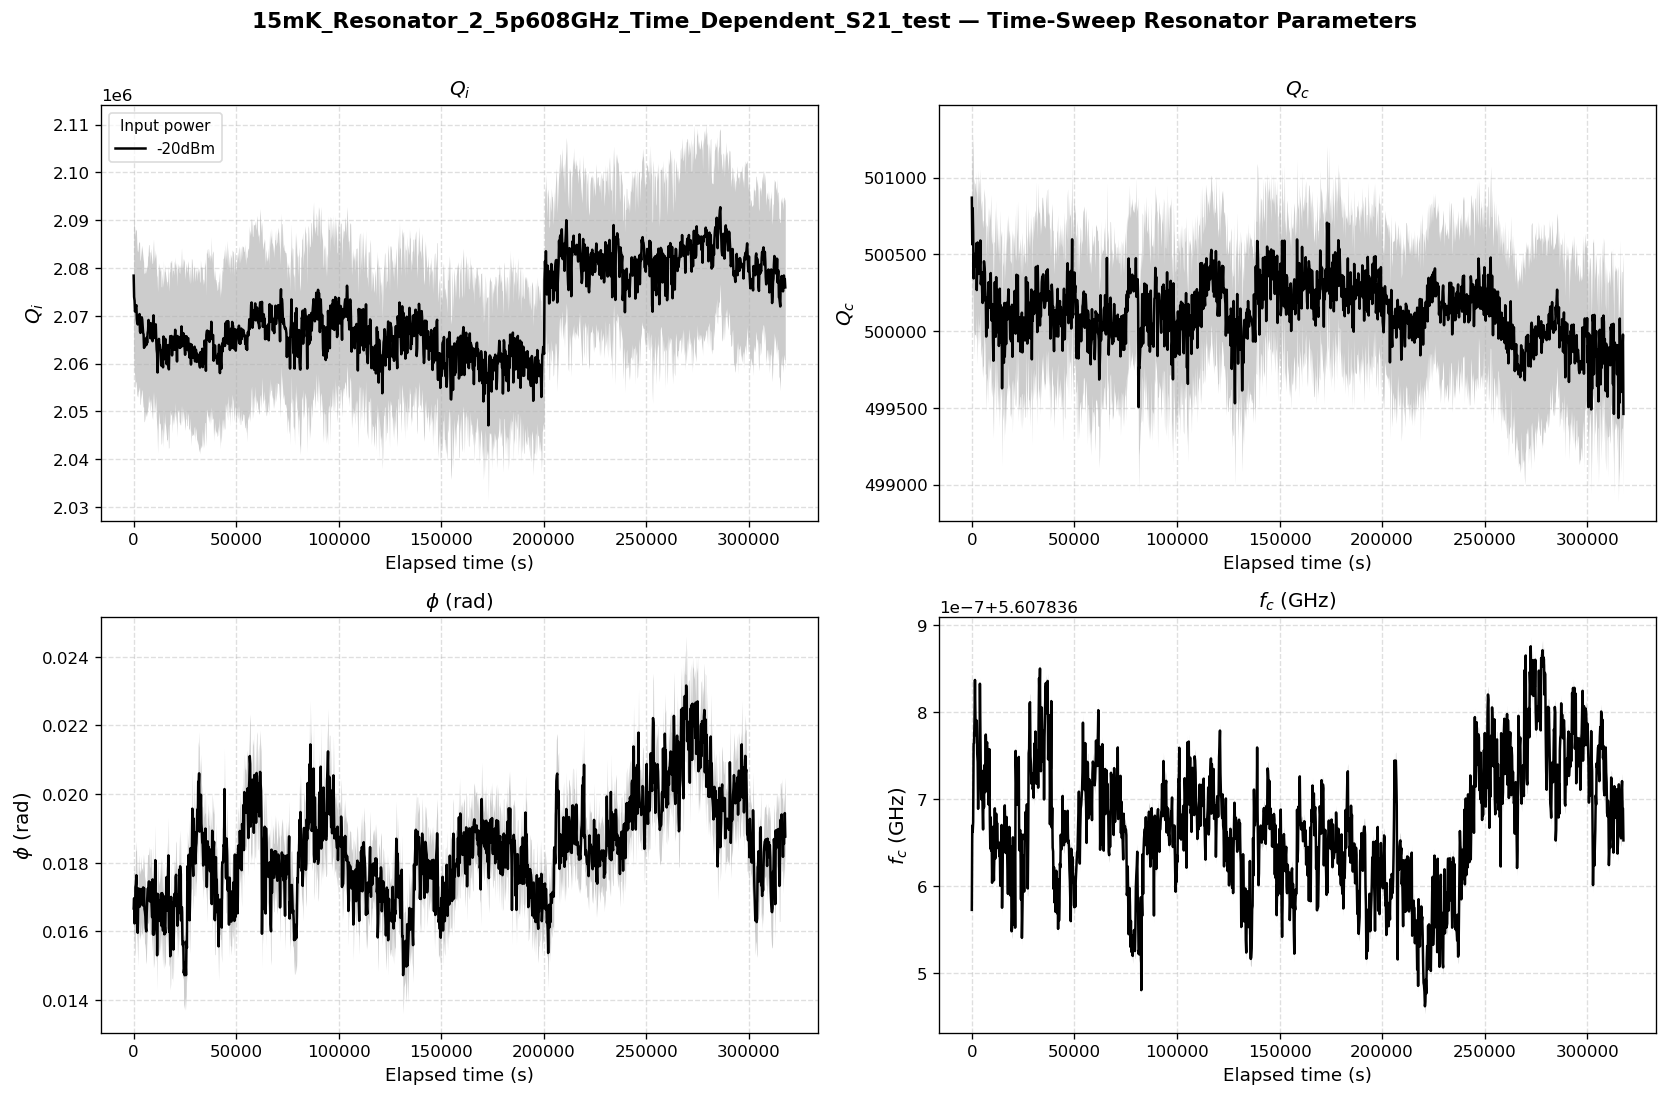

In [140]:
fig_ts = plot_time_sweeps(results, title_prefix=main_folder.name)

if SAVE_PLOTS:
    out_path = main_folder / "time_sweep_parameters.png"
    fig_ts.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")

plt.show()

### Power spectral density of noise

Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test\psd_noise.png


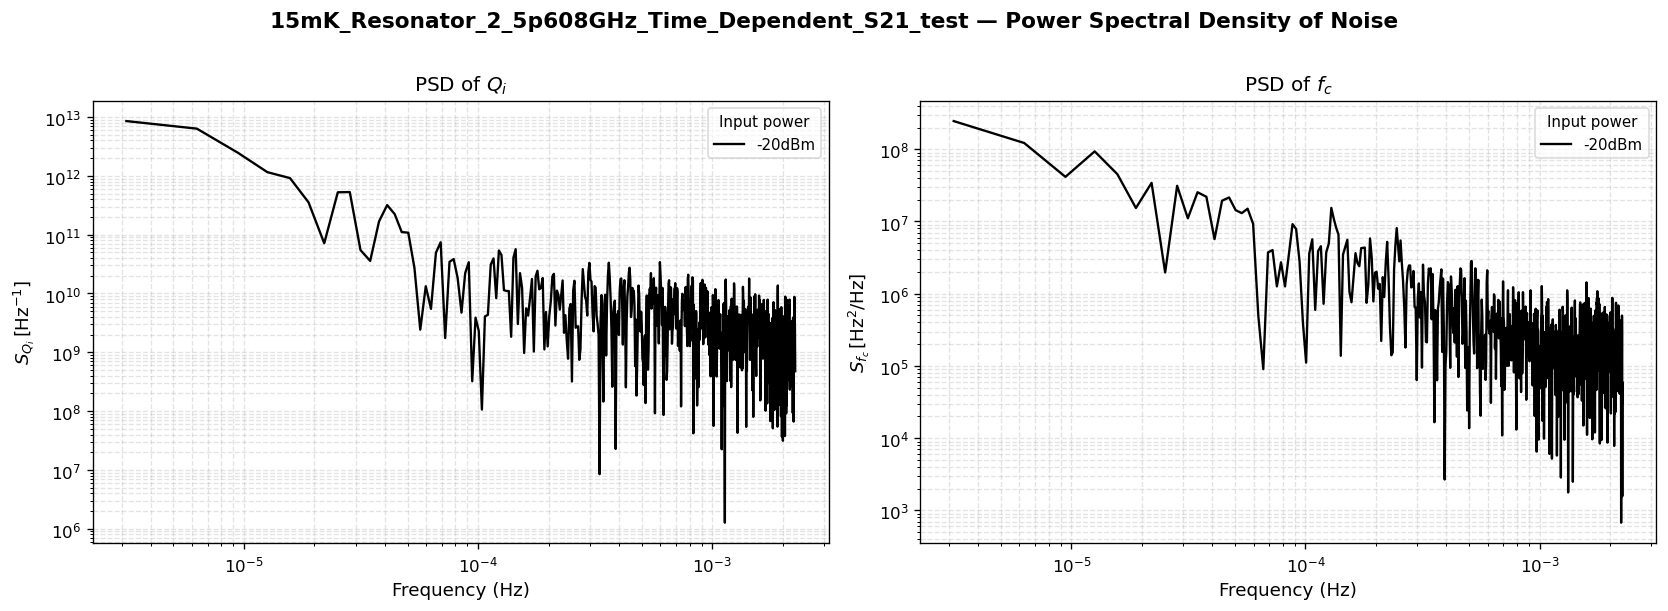

In [141]:
fig_psd = plot_psd(results, title_prefix=main_folder.name)

if SAVE_PLOTS:
    out_path = main_folder / "psd_noise.png"
    fig_psd.savefig(out_path, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out_path}")

plt.show()

### Save fitted parameters

In [142]:
if SAVE_CSVS:
    save_results(results, main_folder)

first_power = sorted(results.keys())[0]
print(f"\nPreview — {first_power}:")
display(results[first_power].head())

21:06:33 [INFO] Saved -> C:\Users\user\OneDrive\文件\GitHub\Measurements\Cooldown_77_Line5-QSD_CPW_w6g3_03\15mK_Resonator_2_5p608GHz_Time_Dependent_S21_test\fitted_params\-20dBm.csv



Preview — -20dBm:


,timestamp,Qi,Qi_err,Qc,Qc_err,phi,phi_err,fc,fc_err
0,1970-01-01 00:00:53.949451447+00:00,2.078396e+06,15547.778108,500869.369576,480.771220,0.016667,0.000969,5.607837,8.468927e-09
1,1970-01-01 00:04:33.512508869+00:00,2.073921e+06,15403.719411,500565.134645,477.669527,0.016966,0.000963,5.607837,8.433627e-09
2,1970-01-01 00:08:13.128776072+00:00,2.073178e+06,15372.255405,500801.300531,477.445412,0.016232,0.000963,5.607837,8.417047e-09
3,1970-01-01 00:11:52.763392210+00:00,2.070891e+06,15653.062107,500644.770195,486.931932,0.016396,0.000984,5.607837,8.581258e-09
4,1970-01-01 00:15:32.449405670+00:00,2.071515e+06,16620.523054,500343.240349,516.186009,0.017296,0.001044,5.607837,9.099972e-09
